Mounted at /content/drive
Đang đọc đồ thị...
Đồ thị gốc: 8000 nodes, 19903 edges
Đang chia tập Train/Test...
Đang tạo Negative edges (Có thể mất một chút thời gian)...
Đang chạy Jaccard Coefficient...
Đang chạy Adamic-Adar Index...

--- KẾT QUẢ ĐÁNH GIÁ ---
AUC của Jaccard Coefficient : 0.7897
AUC của Adamic-Adar Index   : 0.7923

Đã lưu biểu đồ thành file: /content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/auc_chart.png


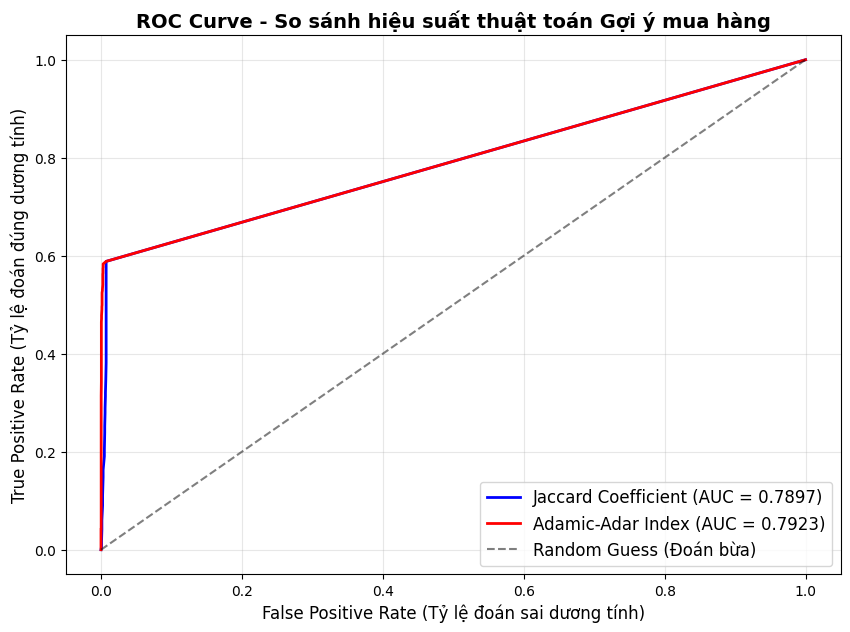

In [ ]:
import networkx as nx
import random
import pickle
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

GRAPH_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/data/processed/amazon_graph.gpickle'
AUC_CHART_PATH = '/content/drive/MyDrive/Colab Notebooks/Do-an-SNA/outputs/figures/auc_chart.png'

# ==========================================
# 1. ĐỌC DỮ LIỆU ĐỒ THỊ
# ==========================================
print("Đang đọc đồ thị...")
# Sử dụng pickle tiêu chuẩn để tránh lỗi trên NetworkX bản mới
with open(GRAPH_PATH, 'rb') as f:
    G = pickle.load(f)
print(f"Đồ thị gốc: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ==========================================
# 2. CHIA TẬP DỮ LIỆU (80% TRAIN - 20% TEST)
# ==========================================
print("Đang chia tập Train/Test...")
edges = list(G.edges())
random.seed(42) # Set seed để kết quả ổn định qua các lần chạy
random.shuffle(edges)

# Lấy 20% làm tập Test (Positive edges - Cạnh thực tế có tồn tại)
num_test = int(0.2 * len(edges))
test_pos_edges = edges[:num_test]
train_edges = edges[num_test:]

# Tạo đồ thị Train (G_train) từ 80% cạnh còn lại
G_train = nx.Graph()
G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_edges)

# Tạo Negative edges cho tập Test (Những cặp node KHÔNG có cạnh nối với nhau)
# Bắt buộc phải có tập này để đánh giá xem mô hình có đoán sai không
test_neg_edges = []
nodes = list(G.nodes())
print("Đang tạo Negative edges (Có thể mất một chút thời gian)...")
while len(test_neg_edges) < num_test:
    u, v = random.sample(nodes, 2)
    # Đảm bảo không có cạnh nối và không bị trùng lặp
    if not G.has_edge(u, v) and (u, v) not in test_neg_edges and (v, u) not in test_neg_edges:
        test_neg_edges.append((u, v))

# Gom toàn bộ tập Test (Positive + Negative) và gán nhãn y_true
test_edges_all = test_pos_edges + test_neg_edges
y_true = [1] * num_test + [0] * num_test # 1 là có cạnh, 0 là không có cạnh

# ==========================================
# 3. CHẠY THUẬT TOÁN (JACCARD & ADAMIC-ADAR)
# ==========================================
print("Đang chạy Jaccard Coefficient...")
jaccard_preds = nx.jaccard_coefficient(G_train, test_edges_all)
y_scores_jaccard = [p for u, v, p in jaccard_preds]

print("Đang chạy Adamic-Adar Index...")
aa_preds = nx.adamic_adar_index(G_train, test_edges_all)
y_scores_aa = [p for u, v, p in aa_preds]

# ==========================================
# 4. ĐÁNH GIÁ AUC-ROC VÀ VẼ BIỂU ĐỒ
# ==========================================
auc_jaccard = roc_auc_score(y_true, y_scores_jaccard)
auc_aa = roc_auc_score(y_true, y_scores_aa)

print("\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"AUC của Jaccard Coefficient : {auc_jaccard:.4f}")
print(f"AUC của Adamic-Adar Index   : {auc_aa:.4f}")

# Vẽ ROC Curve
fpr_j, tpr_j, _ = roc_curve(y_true, y_scores_jaccard)
fpr_a, tpr_a, _ = roc_curve(y_true, y_scores_aa)

plt.figure(figsize=(10, 7))
plt.plot(fpr_j, tpr_j, label=f'Jaccard Coefficient (AUC = {auc_jaccard:.4f})', color='blue', linewidth=2)
plt.plot(fpr_a, tpr_a, label=f'Adamic-Adar Index (AUC = {auc_aa:.4f})', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (Đoán bừa)', alpha=0.5)

plt.xlabel('False Positive Rate (Tỷ lệ đoán sai dương tính)', fontsize=12)
plt.ylabel('True Positive Rate (Tỷ lệ đoán đúng dương tính)', fontsize=12)
plt.title('ROC Curve - So sánh hiệu suất thuật toán Gợi ý mua hàng', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# Lưu hình ảnh và hiển thị
plt.savefig(AUC_CHART_PATH, dpi=300, bbox_inches='tight')
print(f"\nĐã lưu biểu đồ thành file: {AUC_CHART_PATH}")
plt.show()